In [1]:
import os
import cv2
import sys
import copy
import random
import paddle
import numpy as np
import matplotlib.pyplot as plt
from circle_fit import taubinSVD
from openvino.runtime import Core,Dimension
from pre_post_processing import *

In [31]:
# parameters
PADDING = 50
BOX_NUM = 40
OFFSET = 30
FLAGS = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
R_MAX = 4000
MIN_POINTS = 300

path="samples"
samples = os.listdir(path)

In [3]:
#Preprocessing image functions for text detection and recognition
def image_preprocess(input_image, size):
    #img = cv2.resize(input_image, (size,size))
    img = np.transpose(input_image,[2,0,1]) / 255
    img = np.expand_dims(img, 0)
    ##NormalizeImage: {mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225], is_scale: True}
    img_mean = np.array([0.485, 0.456,0.406]).reshape((3,1,1))
    img_std = np.array([0.229, 0.224, 0.225]).reshape((3,1,1))
    img -= img_mean
    img /= img_std
    return img.astype(np.float32)

#Preprocess for Paddle Recognition
def resize_norm_img(img, max_wh_ratio):
        no=48
        rec_image_shape = [3,no, 320] #[3, 32, 320]
        imgC, imgH, imgW = rec_image_shape
        assert imgC == img.shape[2]
        character_type = "ch"
        if character_type == "ch":
            imgW = int((no * max_wh_ratio))
        h, w = img.shape[:2]
        ratio = w / float(h)
        if math.ceil(imgH * ratio) > imgW:
            resized_w = imgW
        else:
            resized_w = int(math.ceil(imgH * ratio))
        resized_image = cv2.resize(img, (resized_w, imgH))
        resized_image = resized_image.astype('float32')
        resized_image = resized_image.transpose((2, 0, 1)) / 255
        resized_image -= 0.5
        resized_image /= 0.5
        padding_im = np.zeros((imgC, imgH, imgW), dtype=np.float32)
        padding_im[:, :, 0:resized_w] = resized_image
        return padding_im
    
def rotateAndScale(img, scaleFactor = 0.5, degreesCCW = 30):
    '''
    rotate image with no cut out vertices
    Args:
        img: original image
        scaleFactor: scale of output image
        degreesCCW: angle (degrees)
    Return:
        rotateImg: rotated image
        M: rotate matrix
    '''
    h,w,c = img.shape #note: numpy uses (y,x) convention but most OpenCV functions use (x,y)
    M = cv2.getRotationMatrix2D(center=(w/2,h/2), angle=degreesCCW, scale=scaleFactor) #rotate about center of image.

    #choose a new image size.
    new_w,new_h = w*scaleFactor,h*scaleFactor
    #include this if you want to prevent corners being cut off
    r = np.deg2rad(degreesCCW)
    new_w,new_h = (abs(np.sin(r)*new_h) + abs(np.cos(r)*new_w),abs(np.sin(r)*new_w) + abs(np.cos(r)*new_h))

    #the warpAffine function call, below, basically works like this:
    # 1. apply the M transformation on each pixel of the original image
    # 2. save everything that falls within the upper-left "dsize" portion of the resulting image.

    #So I will find the translation that moves the result to the center of that region.
    (tx,ty) = ((new_w-w)/2,(new_h-h)/2)
    M[0,2] += tx #third column of matrix holds translation, which takes effect after rotation.
    M[1,2] += ty

    rotatedImg = cv2.warpAffine(img, M, dsize=(int(new_w),int(new_h)))
    return rotatedImg,M

def calc_dist(pt1,pt2):
    '''
    Calculate distance of 2 point
    Args:
        pt1: first point
        pt2: second point
    Return:
        dist: distance
    '''
    dist = cv2.norm(pt1-pt2)
    return dist

def infer_circle(mask):
    '''
    Infer centerpoint, radius of curve
    Args:
        mask: mask of curve image (BGR)
    Return:
        xc: x cord of center point
        yc: y cord of center point
        r: radius
        sigma: sigma
    '''
    # convert image to grayscale
    mask = cv2.cvtColor(mask,cv2.COLOR_BGR2GRAY)
    h,w = mask.shape
    # get first point in mask
    curve = []
    for i in range(w):
        v_line = mask[:,i:i+1]
        pos = cv2.findNonZero(v_line)
        if pos is not None:
            curve.append((pos[0][0][1],i))
    # infer circle by taubinSVD
    xc,yc,r,sigma = taubinSVD(curve)
    return xc,yc,r,sigma

In [32]:
class Extractor:
    def __init__(self):
        self.res=3840 # the resolution range 1280,2560,5120,...
        self.det_compiled_model = None
        self.rec_compiled_model = None
        self.det_input_layer = None # input and nodes for text detection
        self.det_output_layer = None # output nodes for text detection
        self.rec_input_layer = None # input and nodes for text recognition
        self.rec_output_layer = None # output nodes for text recognition
        self.PADDING = 50 # roi padding
        self.BOX_NUM = 40 # maximum box number
        self.OFFSET = 30
        self.FLAGS = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
        self.R_MAX = 4000
        self.MIN_POINTS = 300
    
    def load_model(self,det_model_dir="paddle_ocr/ch_PP-OCRv3_det_infer",
                   rec_model_dir = "paddle_ocr/ch_PP-OCRv3_rec_infer"):
        '''
        Load detection and recognition model
        Args:
            det_model_dir: detection inference model (pretrained)
            rec_model_dir: recognition inference model (pretrained)
        Return:
        Load model into self.det_compiled_model,self.rec_compiled_model
        '''
        #Load Network text detection
        det_model_file_path = det_model_dir + "/inference.pdmodel"
        det_params_file_path = det_model_dir + "/inference.pdiparams"
        
        # initialize inference engine for text detection
        det_ie = Core()
        det_net = det_ie.read_model(model=det_model_file_path, weights=det_params_file_path)
        self.det_compiled_model = det_ie.compile_model(model=det_net, device_name="CPU")
        
        self.det_input_layer = next(iter(self.det_compiled_model.inputs)) ## get input and output nodes for text detection
        self.det_output_layer = next(iter(self.det_compiled_model.outputs))
        
        #Load the Network for Text Recognition
        rec_model_file_path = rec_model_dir + "/inference.pdmodel"
        rec_params_file_path = rec_model_dir + "/inference.pdiparams"

        # Initialize the Paddle recognition inference on CPU
        rec_ie = Core()
        # read the model and corresponding weights from file
        rec_net = rec_ie.read_model(model=rec_model_file_path, weights=rec_params_file_path)

        # assign dynamic shapes to every input layer on the last dimension
        for input_layer in rec_net.inputs:
            input_shape = input_layer.partial_shape
            input_shape[3] = Dimension(-1)
            rec_net.reshape({input_layer: input_shape})
        self.rec_compiled_model = rec_ie.compile_model(model=rec_net, device_name="CPU")
        
        # get input and output nodes
        self.rec_input_layer = next(iter(self.rec_compiled_model.inputs))
        self.rec_output_layer = next(iter(self.rec_compiled_model.outputs))
        
    def read_image(self,img_path):
        '''
        Read the image
        Args:
            img_path: image path
        Return:
            image_file: scaled image
            test_image: preprocessed array of image
        '''
        # read the image
        image = cv2.imread(img_path)
        res= self.res

        # if frame larger than full HD, reduce size to improve the performance
        scale = res/max(image.shape)

        if scale < 1:
            # resize image
            image = cv2.resize(src=image, dsize=None, fx=scale, fy=scale,interpolation=cv2.INTER_AREA)
            image_file = image
            test_image = image_preprocess(image_file,self.res)
        else:
            image_file = image
            test_image = image_preprocess(image_file,self.res)
        return image_file,test_image
    
    def detect(self,image_file,test_image):
        '''
        Extract roi (text regions)
        Args:
            image_file:
            test_image:
        Return:
            dt_boxes: list of detected boxes,example: [(4,2),(4,2),...] 
            mask: binary mask of image
        '''
        # Create dectect infer request
        det_request = self.det_compiled_model.create_infer_request()

        #perform the inference step
        det_request.infer(inputs = {self.det_input_layer.any_name: test_image})
        det_results = det_request.get_tensor(self.det_output_layer).data
        
        # Postprocessing for Paddle Detection
        ori_im = image_file.copy()
        data = {'image': image_file}
        data_resize = DetResizeForTest(data)
        data_norm = NormalizeImage(data_resize)
        data_list = []
        keep_keys =  ['image', 'shape']
        
        for key in keep_keys:
            data_list.append(data_resize[key]) #
        img, shape_list = data_list
        shape_list = np.expand_dims(shape_list, axis=0)
        pred = det_results[0]
        
        if isinstance(pred, paddle.Tensor):
            pred = pred.numpy()
        segmentation = pred > 0.3
        boxes_batch = []
        
        for batch_index in range(pred.shape[0]):
            src_h, src_w, ratio_h, ratio_w = shape_list[batch_index]
            mask = segmentation[batch_index]
            boxes, scores = boxes_from_bitmap(pred[batch_index], mask,src_w, src_h) # boxes (n, 4, 2), scores list of coff
            boxes_batch.append({'points': boxes})
        post_result = boxes_batch # list of {'points':[[]]}
        dt_boxes = post_result[0]['points'] # (n,4,2)
        dt_boxes = filter_tag_det_res(dt_boxes, ori_im.shape)
        
        #Preprocess detection results for recognition
        dt_boxes = sorted_boxes(dt_boxes)
        return dt_boxes,mask
    
    def crop(self,image_file,test_image):
        '''
        Extract copped roi
        Args:
            image_file:
            test_image:
        Return:
        '''
        pass
    
    def recognize(self):
        pass
    
    def infer(self,img_path):
        '''
        Inference text detection and tex recognition
        Args:
            img_path: image path
        Return:
        '''
        # Read the image
        image_file,test_image=self.read_image(img_path)
        ori_im = image_file.copy()
        
        # text detection
        dt_boxes,_ = self.detect(image_file,test_image)
        
        img_crop_list = []   
        if dt_boxes != []:
            for bno in range(len(dt_boxes)):
                tmp_box = copy.deepcopy(dt_boxes[bno])
                img_crop = get_rotate_crop_image(ori_im, tmp_box)
                img_crop_list.append(img_crop)
                
            #Recognition starts from here
            img_num = len(img_crop_list)

            # Calculate the aspect ratio of all text bars
            width_list = []
            for img in img_crop_list:
                width_list.append(img.shape[1] / float(img.shape[0]))

            # Sorting can speed up the recognition process
            indices = np.argsort(np.array(width_list))
            rec_res = [['', 0.0]] * img_num
            batch_num = 6
            rec_processing_times = 0

            #For each detected text box, run inference for text recognition
            for beg_img_no in range(0, img_num, batch_num):
                end_img_no = min(img_num, beg_img_no + batch_num)

                norm_img_batch = []
                max_wh_ratio = 0
                for ino in range(beg_img_no, end_img_no):
                    h, w = img_crop_list[indices[ino]].shape[0:2]
                    wh_ratio = w * 1.0 / h
                    max_wh_ratio = max(max_wh_ratio, wh_ratio)
                for ino in range(beg_img_no, end_img_no):
                    norm_img = resize_norm_img(img_crop_list[indices[ino]],max_wh_ratio)
                    norm_img = norm_img[np.newaxis, :]
                    norm_img_batch.append(norm_img)

                norm_img_batch = np.concatenate(norm_img_batch)
                norm_img_batch = norm_img_batch.copy()

                #Run inference for text recognition
                rec_request = self.rec_compiled_model.create_infer_request()
                rec_request.infer(inputs={self.rec_input_layer.any_name: norm_img_batch})
                rec_results = rec_request.get_tensor(self.rec_output_layer).data
                preds = rec_results

                #Postprocessing recognition results
                postprocess_op = build_post_process(postprocess_params)
                rec_result = postprocess_op(preds)
                for rno in range(len(rec_result)):
                    rec_res[indices[beg_img_no + rno]] = rec_result[rno]

                #Text recognition results, rec_res, include two parts:
                #txts are the recognized text results, scores are the recognition confidence level                   
                if rec_res != []:
                    img = Image.fromarray(cv2.cvtColor(image_file, cv2.COLOR_BGR2RGB))
                    boxes = dt_boxes
                    txts = [rec_res[i][0] for i in range(len(rec_res))] 
                    scores = [rec_res[i][1] for i in range(len(rec_res))]

                    #draw text recognition results beside the image
                    # remove pred samller than drop_score
                    draw_img = draw_ocr_box_txt(img,boxes,txts,scores,drop_score=0.2) 
        return rec_res,draw_img

# infer

In [6]:
extractor = Extractor()
extractor.load_model()

/home/greystone/locchuong/ocr-exp/pre_post_processing.py:115: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  xmin = np.clip(np.floor(box[:, 0].min()).astype(np.int), 0, w - 1)
/home/greystone/locchuong/ocr-exp/pre_post_processing.py:116: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, c

[('US', 0.9545791), ('LISTED', 0.99147266), ('ITEE358912', 0.9707627), ('BuiltinVietnam', 0.9518189), ('SN:1A221J3D51WHG7', 0.95556617), ('Setupcode:35RNYF', 0.92311823)]


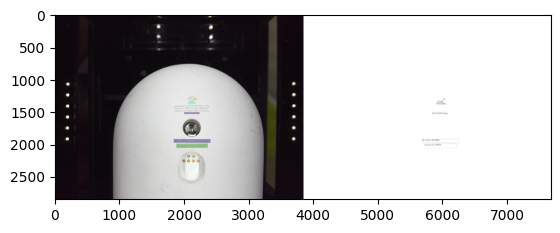

In [7]:
rec_res,draw_img=extractor.infer("irregular/05.jpg")
print(rec_res)
plt.imshow(draw_img)

# detect

boxs 15


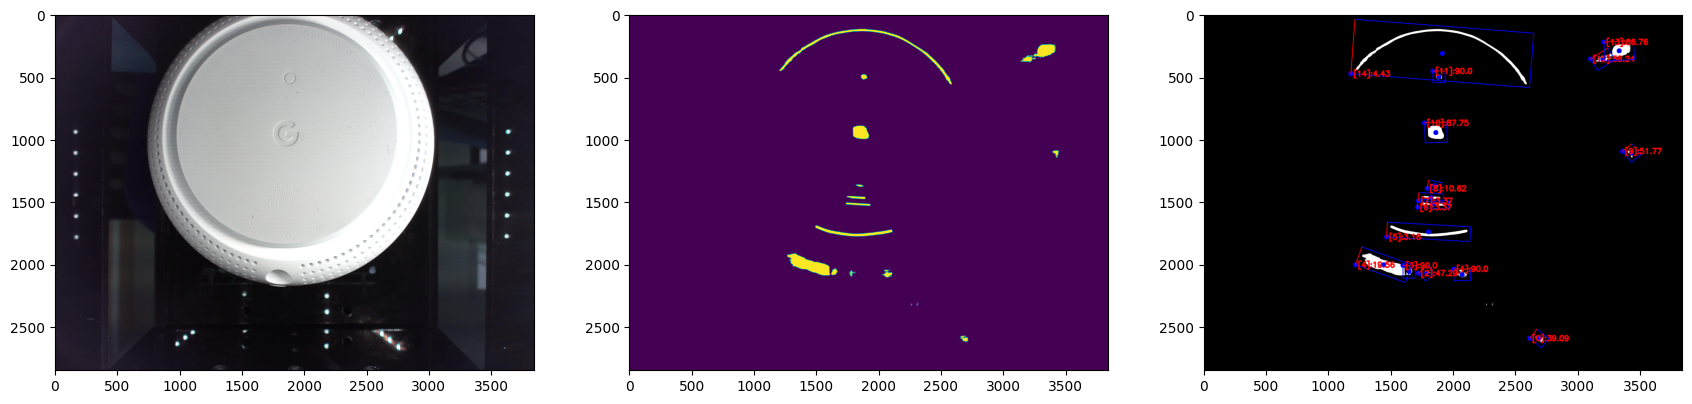

In [33]:
# detect mask
image_name=random.choice(samples)
#samples/20. Google Nest Wifi Point_H2E-Google.jpg
image_file,test_image=extractor.read_image("samples/20. Google Nest Wifi Point_H2E-Google.jpg")#os.path.join(path,image_name)
dt_boxes,mask = extractor.detect(image_file,test_image)

# find contours
contours, hierarchy = cv2.findContours(mask.astype("uint8"),cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# select suitable area
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)
    
# select suitable area
cnts = []
s_min = np.array(areas).mean()
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > s_min:
        cnts.append(cnt)
        
merged = cv2.merge([mask.astype("uint8"),mask.astype("uint8"),mask.astype("uint8")]) *255
draw_img = merged.copy()

regs =[] # maximum rec
boxs = [] # minimum rec 4-point 
rects = [] # minimum rec
slopes = [] # degree

for i,cnt in enumerate(cnts):
    # maximum rect
    x_m,y_m,w_m,h_m = cv2.boundingRect(cnt)
    regs.append((x_m,y_m,w_m,h_m))
    
    # roated rect (minimum rect)
    rect = cv2.minAreaRect(cnt)
    
    # angles of minrect
    slope = rect[-1]
    slopes.append(slope)
    
    # new rect add padding
    h = int(rect[1][0]+ PADDING)
    w = int(rect[1][1]+ PADDING)
    new_rect = (rect[0],(h,w),slope) #h,w
    rects.append(new_rect)
    box = cv2.boxPoints(new_rect)
    box = np.int0(box)
    boxs.append(box)
    
    # draw
    #cv2.rectangle(img,(x_m,y_m),(x_m+w_m,y_m+h_m),(0,255,0),6) # max rect
    cv2.drawContours(draw_img,[box],0,(0,0,255),6) # min rect
    cv2.circle(draw_img,(int(rect[0][0]),int(rect[0][1])),20,(0,0,255),-1)# top point
    cv2.circle(draw_img,box[0],20,(0,0,255),-1)# top point
    cv2.line(draw_img,box[0],box[1],(255,0,0),6)# top line
    cv2.putText(draw_img,f"[{i}]:{round(slope,2)}",box[0]+np.array([20,20]),
                cv2.FONT_HERSHEY_SIMPLEX,2,(255,0,0),10, cv2.LINE_AA) # angle

print(f"boxs {len(boxs)}")

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(21, 12))
axes[0].imshow(image_file)
axes[1].imshow(mask)
axes[2].imshow(draw_img)

In [34]:
rois = []
masks = []

if len(boxs) < BOX_NUM:
    for i,t in enumerate(slopes):
        # original input
        img = image_file.copy()
        img_mask = merged.copy()
        rect = rects[i]
        box = boxs[i] # 4 pts form of rect
        rebox = box.reshape(-1,1,2)
        #rotate
        img,M = rotateAndScale(img, scaleFactor = 2.0, degreesCCW = t)
        img_mask,_ = rotateAndScale(img_mask, scaleFactor = 2.0, degreesCCW = t)
        rebox = cv2.transform(rebox, M) # what you need
        # find new top left,bottom right
        dist = []
        for pt in rebox.reshape(-1,2):
            d = calc_dist(np.array([0,0]),pt)
            dist.append(d)
        top_left = rebox.reshape(-1,2)[np.argmin(dist)]
        bottom_right = rebox.reshape(-1,2)[np.argmax(dist)]
        w,h = bottom_right - top_left
        x,y = top_left
        # roi of original and mask
        out = img[y:y+h,x:x+w]
        # zero dim
        if(out.shape[0]*out.shape[1]==0):
            continue
        out_m = img_mask[y:y+h,x:x+w]
        rois.append(out)
        masks.append(out_m)
        # double by 180 rotate
        #out = cv2.rotate(out,cv2.ROTATE_180)
        #rois.append(out)
        out_m = cv2.rotate(out_m,cv2.ROTATE_180)
        masks.append(out_m)

else:
    print("overloaded!")
    for i,_ in enumerate(boxs):
        # original input
        img = img_org.copy()
        img_mask = mask3.copy()
        # read rec
        x,y,w,h = mboxs[i]
        x = x - padding if x - padding > 0 else 0
        y = y - padding if y - padding > 0 else 0
        # roi of original and mask
        out = img[y:y+h+padding,x:x+w+padding]
        # zero dim
        if(out.shape[0]*out.shape[1]==0):
            continue
        out_m = img_mask[y:y+h,x:x+w]
        rois.append(out)
        masks.append(out_m)
        # double by 180 rotate
        #out = cv2.rotate(out,cv2.ROTATE_180)
        #rois.append(out)
        out_m = cv2.rotate(out_m,cv2.ROTATE_180)
        masks.append(out_m)
    
if len(rois) >0:
    
    # rotate
    for i,roi in enumerate(rois):
        h,w,c = roi.shape
        if h > w:
            rois[i] = cv2.rotate(rois[i],cv2.ROTATE_90_CLOCKWISE)
            masks[i] = cv2.rotate(masks[i],cv2.ROTATE_90_CLOCKWISE)
else:
    print("empty roi!")

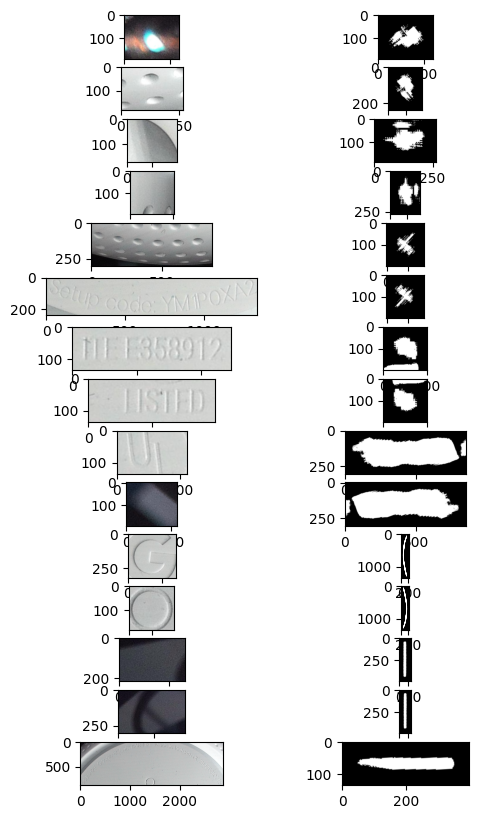

In [35]:
# plot roi
fig, axes = plt.subplots(nrows=len(rois), ncols=2, figsize=(6,10))
for i in range(len(rois)):
    axes[i][0].imshow(rois[i])
    axes[i][1].imshow(masks[i])

In [36]:
def warp_img(mask,roi,xc,yc,r):
    '''
    '''
    r=int(r)
    mask = cv2.cvtColor(mask,cv2.COLOR_BGR2GRAY)
    h,w = mask.shape
    # curve
    curve = [] # limit 300
    for i in range(w):
        v_line = mask[:,i:i+1]
        pos = cv2.findNonZero(v_line)
        if pos is not None:
            curve.append((pos[0][0][1],i))
    if (r < R_MAX) and (len(curve) > MIN_POINTS):
        if xc<0:
            mask = cv2.rotate(mask,cv2.ROTATE_180)
            roi = cv2.rotate(roi,cv2.ROTATE_180)
            x = int(r - w/2)
            y = 2*r-h
            x2 = x+w
            y2 = 2*r
        else:
            x = int(r - w/2)
            y = 0
            x2 = x+w
            y2 = h

        blank = np.zeros((r*2,r*2,3)).astype(np.uint8)
        blank_mask = np.zeros((r*2,r*2,3)).astype(np.uint8)
        blank[y:y2,x:x2]= roi
        blank_mask[y:y2,x:x2]= mask

        polar_img = cv2.warpPolar(blank,(r,r*2),(r,r),r+300,FLAGS) # w,h
        polar_mask = cv2.warpPolar(blank_mask,(r,r*2),(r,r),r+300,FLAGS) # w,h
        out = polar_img.transpose(1,0,2)[::-1]
        out_m = polar_mask.transpose(1,0,2)[::-1].astype(np.uint8)

        gray = cv2.cvtColor(out_m, cv2.COLOR_BGR2GRAY)
        ret, thresh = cv2.threshold(gray, 127, 255, 0)
        contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        areas = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            areas.append(area)

        cnt_max = contours[np.argmax(areas)]
        xr,yr,w,h = cv2.boundingRect(cnt_max)

        x0=xr-OFFSET
        y0=yr-OFFSET
        x1=xr+w+OFFSET
        y1=yr+h+OFFSET

        out = out[y0:y1,x0:x1]
    else:
        out = roi
        
    out_180 = cv2.rotate(out,cv2.ROTATE_180)
    return out,out_180

/home/greystone/locchuong/ocr-exp/env/lib/python3.8/site-packages/circle_fit/circle_fit.py:403: RuntimeWarning: divide by zero encountered in divide
  c = -(A[1:3]).transpose() / A[0] / 2 + centroid
/home/greystone/locchuong/ocr-exp/env/lib/python3.8/site-packages/circle_fit/circle_fit.py:403: RuntimeWarning: invalid value encountered in divide
  c = -(A[1:3]).transpose() / A[0] / 2 + centroid
/home/greystone/locchuong/ocr-exp/env/lib/python3.8/site-packages/circle_fit/circle_fit.py:406: RuntimeWarning: divide by zero encountered in double_scalars
  r = np.sqrt(A[1] * A[1] + A[2] * A[2] - 4 * A[0] * A[3]) / abs(A[0]) / 2


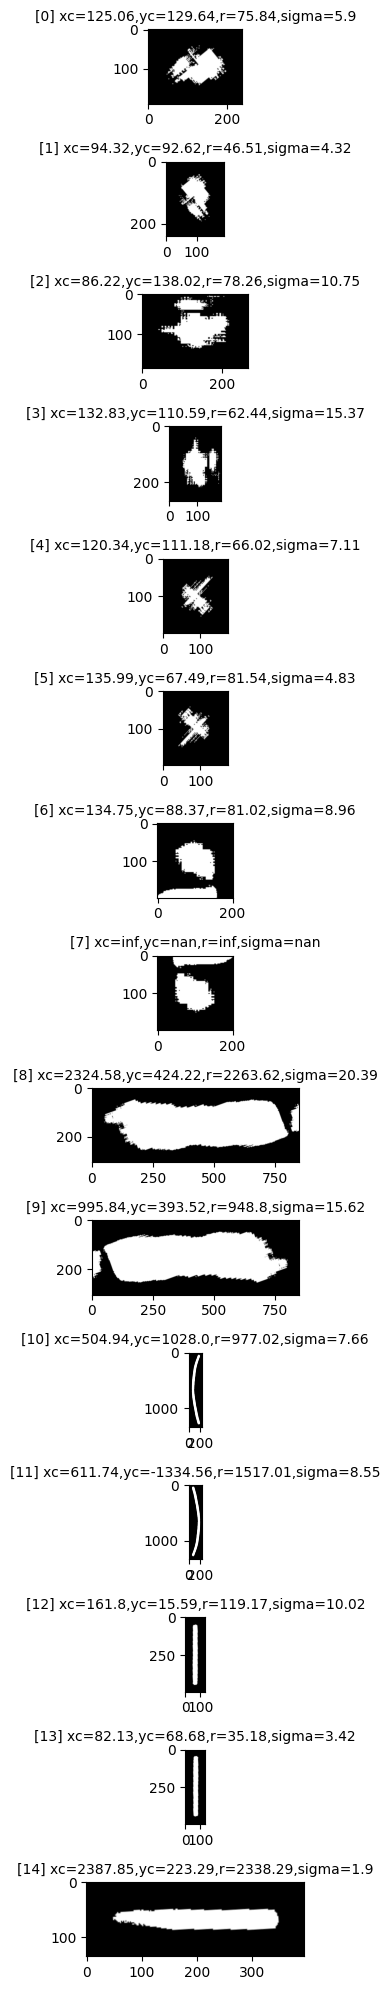

In [37]:
fig, axes = plt.subplots(nrows=len(rois), ncols=1, figsize=(10,20))
for i in range(len(rois)):
    axes[i].imshow(masks[i])
    xc,yc,r,sigma = infer_circle(masks[i])
    axes[i].set_title(f"[{i}] xc={round(xc,2)},yc={round(yc,2)},r={round(r,2)},sigma={round(sigma,2)}", fontsize =10)
plt.tight_layout()

62.435720761631266


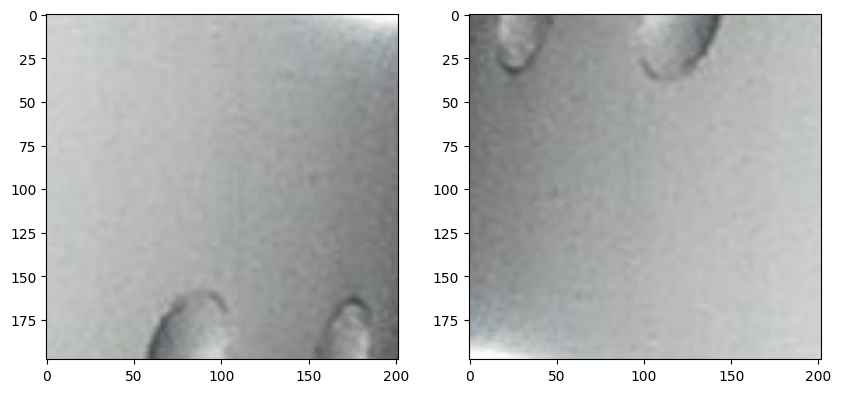

In [38]:
idx = 3 #-7,-8

xc,yc,r,sigma = infer_circle(masks[idx])
print(r)
out,out_180 = warp_img(masks[idx],rois[idx],xc,yc,r)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,10))
for i in range(2):
    axes[0].imshow(out)
    axes[1].imshow(out_180)

In [12]:
out.shape

(342, 314, 3)

# recognize